# Black-Scholes: put-call parity and price sensitivity to spot

Two checks on `pricing.black_scholes.black_scholes_price`:

1. **Put-call parity**: $C - P = S e^{-qT} - K e^{-rT}$ must hold numerically for any valid inputs.
2. **Price vs. spot**: plot call and put price as a function of the underlying price $S$, holding everything else fixed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pricing.black_scholes import black_scholes_price

# Fixed seed for reproducibility of any randomness introduced later in the notebook.
RNG_SEED = 42
np.random.seed(RNG_SEED)

## 1. Put-call parity check

In [2]:
# Market parameters
S0 = 100.0   # spot price
K = 100.0    # strike
T = 1.0      # time to maturity (years)
r = 0.05     # risk-free rate
sigma = 0.20 # volatility
q = 0.02     # continuous dividend yield

call_price = black_scholes_price(S0, K, T, r, sigma, option_type="call", q=q)
put_price = black_scholes_price(S0, K, T, r, sigma, option_type="put", q=q)

lhs = call_price - put_price
rhs = S0 * np.exp(-q * T) - K * np.exp(-r * T)

print(f"Call price: {call_price:.6f}")
print(f"Put price:  {put_price:.6f}")
print(f"C - P (lhs):            {lhs:.6f}")
print(f"S*exp(-qT) - K*exp(-rT) (rhs): {rhs:.6f}")
print(f"Absolute difference:    {abs(lhs - rhs):.2e}")

assert np.isclose(lhs, rhs, atol=1e-10), "Put-call parity violated!"

Call price: 9.227006
Put price:  6.330081
C - P (lhs):            2.896925
S*exp(-qT) - K*exp(-rT) (rhs): 2.896925
Absolute difference:    0.00e+00


## 2. Price vs. spot

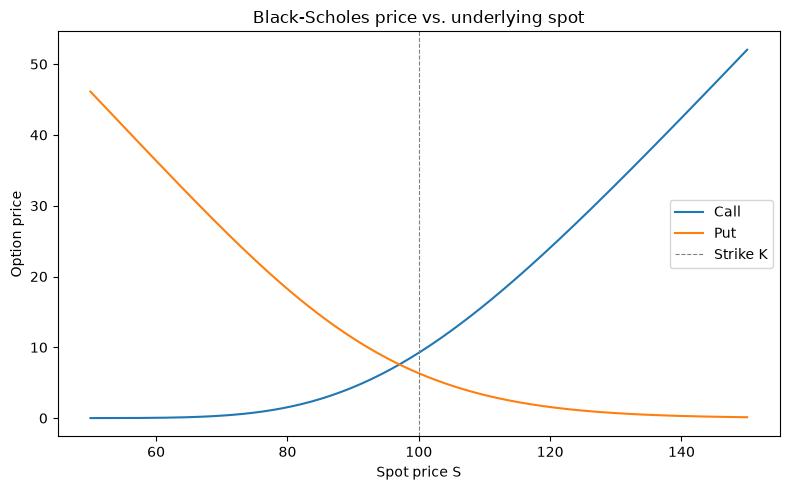

In [3]:
spot_grid = np.linspace(50, 150, 200)
call_prices = [black_scholes_price(S, K, T, r, sigma, option_type="call", q=q) for S in spot_grid]
put_prices = [black_scholes_price(S, K, T, r, sigma, option_type="put", q=q) for S in spot_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(spot_grid, call_prices, label="Call")
ax.plot(spot_grid, put_prices, label="Put")
ax.axvline(K, color="gray", linestyle="--", linewidth=0.8, label="Strike K")
ax.set_xlabel("Spot price S")
ax.set_ylabel("Option price")
ax.set_title("Black-Scholes price vs. underlying spot")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Position payoffs and the synthetic forward

Terminal payoffs (at maturity, as a function of $S_T$) for the four basic positions, and a check that **long call + short put reproduces a forward's payoff exactly** ($S_T - K$ in every scenario) — the mechanical reason put-call parity holds.

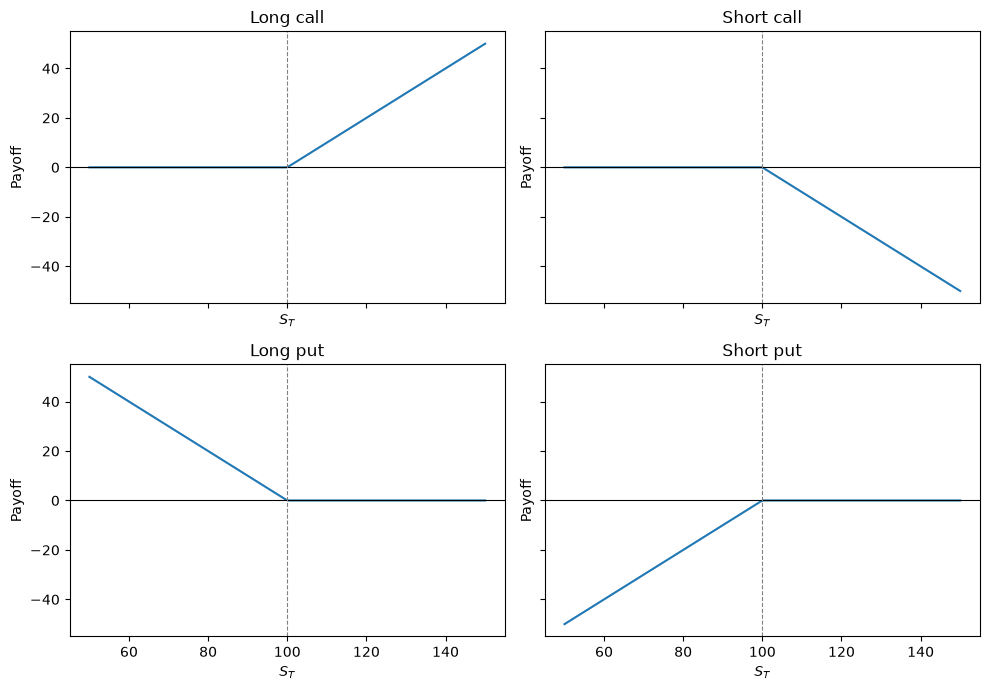

In [4]:
S_T_grid = np.linspace(50, 150, 200)

long_call_payoff = np.maximum(S_T_grid - K, 0.0)
short_call_payoff = -long_call_payoff
long_put_payoff = np.maximum(K - S_T_grid, 0.0)
short_put_payoff = -long_put_payoff

positions = [
    ("Long call", long_call_payoff),
    ("Short call", short_call_payoff),
    ("Long put", long_put_payoff),
    ("Short put", short_put_payoff),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, (title, payoff) in zip(axes.flat, positions):
    ax.plot(S_T_grid, payoff)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(K, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("$S_T$")
    ax.set_ylabel("Payoff")
fig.tight_layout()
plt.show()

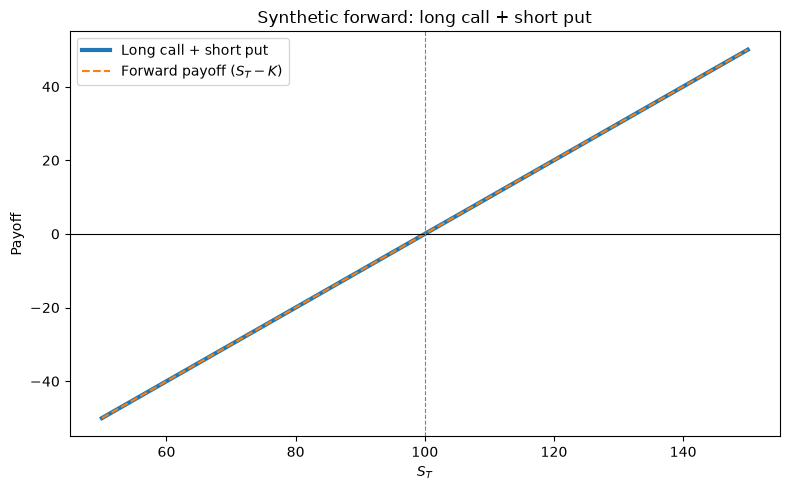

In [5]:
# Long call + short put should reproduce a plain forward payoff: S_T - K
synthetic_forward_payoff = long_call_payoff + short_put_payoff
forward_payoff = S_T_grid - K

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S_T_grid, synthetic_forward_payoff, label="Long call + short put", linewidth=3)
ax.plot(S_T_grid, forward_payoff, label="Forward payoff ($S_T - K$)", linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(K, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("$S_T$")
ax.set_ylabel("Payoff")
ax.set_title("Synthetic forward: long call + short put")
ax.legend()
fig.tight_layout()
plt.show()

assert np.allclose(synthetic_forward_payoff, forward_payoff), "Synthetic forward does not match a plain forward!"